<a href="https://colab.research.google.com/github/mthudangn/llm-therapy-fidelity/blob/experiment/notebooks/thesis_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# I. Introduction

## 1.1. Library and Dataset Import

In [29]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import files

In [30]:
LOCAL_PATH = "/content/AnnoMI-full.csv"

def load_data():
    global _df_cache

    # 1. Memory cache
    if '_df_cache' in globals() and _df_cache is not None:
        print("---> Load data from in-memory cache")
        return _df_cache

    # 2. Local storage
    if os.path.exists(LOCAL_PATH):
        print("---> Load data from local")
        _df_cache = pd.read_csv(LOCAL_PATH)
        return _df_cache

    # 3. GitHub
    try:
        print("---> Load data from GitHub")
        github_url = "https://raw.githubusercontent.com/mthudangn/llm-therapy-fidelity/experiment/data/AnnoMI-full.csv"
        _df_cache = pd.read_csv(github_url)
        _df_cache.to_csv(LOCAL_PATH, index=False)
        return _df_cache
    except Exception as e:
        print("GitHub access expired - ", e)

    # 4. Google Drive
    drive_url = "https://drive.google.com/uc?id=1J6v0T4kFXGY_OEZXo-_0SYBLhwLy8qtl"
    try:
        print("---> Load data from Google Drive")
        _df_cache = pd.read_csv(drive_url)
        _df_cache.to_csv(LOCAL_PATH, index=False)
        return _df_cache
    except Exception:
        pass

    # 5. Manual download & upload
    print("⚠️ Please download file:\n" + drive_url + "\nand upload AnnoMI-full.csv manually")
    uploaded = files.upload()

    filename = list(uploaded.keys())[0]
    _df_cache = pd.read_csv(filename)
    _df_cache.to_csv(LOCAL_PATH, index=False)

    return _df_cache

df = load_data()

---> Load data from in-memory cache


In [31]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13551, 18)


,mi_quality,transcript_id,video_title,video_url,topic,utterance_id,interlocutor,timestamp,utterance_text,annotator_id,therapist_input_exists,therapist_input_subtype,reflection_exists,reflection_subtype,question_exists,question_subtype,main_therapist_behaviour,client_talk_type
0,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,0,therapist,00:00:13,Thanks for filling it out. We give this form t...,3,False,NaN,False,NaN,True,open,question,NaN
1,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,1,client,00:00:24,Sure.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
2,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,2,therapist,00:00:25,"So, let's see. It looks that you put-- You dri...",3,True,information,False,NaN,False,NaN,therapist_input,NaN
3,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,3,client,00:00:34,Mm-hmm.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
4,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,4,therapist,00:00:34,-and you usually have three to four drinks whe...,3,True,information,False,NaN,False,NaN,therapist_input,NaN


The original dataset contains multiple annotations per utterance. These annotations are aggregated into a single consensus label using majority voting, resulting in an utterance-level dataset used for EDA.

In [32]:
# Build utterance-level consensus dataframe
# Purpose:
# - Collapse repeated annotations for the same utterance
# - Keep one final row per (transcript_id, utterance_id)
# - Keep only columns needed for EDA & modelling

def mode_or_nan(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    s = s[s.str.lower() != "nan"]
    if len(s) == 0:
        return np.nan
    return s.mode().iloc[0]

keep_cols = [
    "transcript_id",
    "utterance_id",
    "mi_quality",
    "interlocutor",
    "utterance_text",
    "main_therapist_behaviour",
    "client_talk_type",
]

use_cols = [c for c in keep_cols if c in df.columns]

df_small = df[use_cols].copy()


# Majority vote of annotators
df_consensus = (
    df_small
    .groupby(["transcript_id", "utterance_id"], as_index=False)
    .agg({
        "mi_quality": mode_or_nan,
        "interlocutor": mode_or_nan,
        "utterance_text": mode_or_nan,
        "main_therapist_behaviour": mode_or_nan,
        "client_talk_type": mode_or_nan,
    })
    .sort_values(["transcript_id", "utterance_id"])
    .reset_index(drop=True)
)

for col in ["mi_quality", "interlocutor", "main_therapist_behaviour", "client_talk_type"]:
    if col in df_consensus.columns:
        df_consensus[col] = df_consensus[col].astype(str).str.strip().str.lower()
        df_consensus.loc[df_consensus[col] == "nan", col] = np.nan

print("Raw shape:", df.shape)
print("Consensus shape:", df_consensus.shape)
print(
    "Remaining duplicate utterances:",
    df_consensus.duplicated(subset=["transcript_id", "utterance_id"]).sum()
)

Raw shape: (13551, 18)
Consensus shape: (9699, 7)
Remaining duplicate utterances: 0


## 1.2. Data Inspection

In [33]:
print("Columns:")
print(df_consensus.columns.tolist())
print("\nData types:")
print(df_consensus.dtypes)
print("\nMissing values:")
print(df_consensus.isna().sum())

Columns:
['transcript_id', 'utterance_id', 'mi_quality', 'interlocutor', 'utterance_text', 'main_therapist_behaviour', 'client_talk_type']

Data types:
transcript_id                int64
utterance_id                 int64
mi_quality                  object
interlocutor                object
utterance_text              object
main_therapist_behaviour    object
client_talk_type            object
dtype: object

Missing values:
transcript_id                  0
utterance_id                   0
mi_quality                     0
interlocutor                   0
utterance_text                 0
main_therapist_behaviour    4817
client_talk_type            4882
dtype: int64


In [34]:
display(df_consensus.sample(min(5, len(df_consensus)), random_state=42))

,transcript_id,utterance_id,mi_quality,interlocutor,utterance_text,main_therapist_behaviour,client_talk_type
1285,22,60,high,therapist,I really applaud you for being open-minded eno...,other,NaN
3047,49,9,high,client,Mm.,NaN,neutral
1954,34,90,high,therapist,You're concerned that they're gonna kind of tr...,reflection,NaN
7463,108,52,high,therapist,"Okay, okay. Good. Um, I think you've got a goo...",question,NaN
39,0,39,high,client,"Well, I'm more ready than a six because I'm re...",NaN,change


### Value counts for important categorical columns, including subtype columns

In [35]:
for col in [
    "interlocutor",
    "main_therapist_behaviour",
    "client_talk_type",
    "mi_quality",
    "question_exists",
    "question_subtype",
    "reflection_exists",
    "reflection_subtype",
    "therapist_input_subtype"
]:
    if col in df.columns:
        print(f"\n===== {col} =====")
        print(df[col].value_counts(dropna=False))



===== interlocutor =====
interlocutor
therapist    6826
client       6725
Name: count, dtype: int64

===== main_therapist_behaviour =====
main_therapist_behaviour
NaN                6725
other              2143
question           1954
reflection         1717
therapist_input    1012
Name: count, dtype: int64

===== client_talk_type =====
client_talk_type
NaN        6826
neutral    4217
change     1668
sustain     840
Name: count, dtype: int64

===== mi_quality =====
mi_quality
high    12286
low      1265
Name: count, dtype: int64

===== question_exists =====
question_exists
NaN      6725
False    4513
True     2313
Name: count, dtype: int64

===== question_subtype =====
question_subtype
NaN       11238
open       1340
closed      973
Name: count, dtype: int64

===== reflection_exists =====
reflection_exists
NaN      6725
False    4805
True     2021
Name: count, dtype: int64

===== reflection_subtype =====
reflection_subtype
NaN        11530
simple      1070
complex      951
Name: count

### Therapist and Client Data Split

Each utterance is assigned a single dominant behaviour label, while additional annotation fields capture the presence of multiple behavioural elements, enabling analysis of intervention fidelity beyond simple classification.

In [36]:
therapist_df = df_consensus[df_consensus["interlocutor"] == "therapist"].copy()
client_df = df_consensus[df_consensus["interlocutor"] == "client"].copy()

print("---> Therapist rows shape:", therapist_df.shape)
print("---> Client rows shape   :", client_df.shape)

print("\n---> Therapist behaviour labels:")
print(therapist_df["main_therapist_behaviour"].value_counts(dropna=False))

print("\n---> Client talk labels:")
print(client_df["client_talk_type"].value_counts(dropna=False))

---> Therapist rows shape: (4882, 7)
---> Client rows shape   : (4817, 7)

---> Therapist behaviour labels:
main_therapist_behaviour
other              1587
question           1386
reflection         1297
therapist_input     612
Name: count, dtype: int64

---> Client talk labels:
client_talk_type
neutral    3101
change     1177
sustain     539
Name: count, dtype: int64


Behavioural complexity was quantified by counting the number of behavioural indicators (i.e., question, reflection, and therapist input) present in each therapist utterance.

The distribution indicates that the majority of utterances contain a single behavioural element (n = 3,876), consistent with the dataset’s single-label annotation scheme. A substantial proportion of utterances contain no behavioural signals (n = 2,143), corresponding to non-therapeutic or filler dialogue. Additionally, a smaller subset of utterances exhibits multiple behavioural elements (n = 747 for two behaviours and n = 60 for three behaviours), indicating that therapist responses may simultaneously fulfil multiple communicative functions.

These results demonstrate that, although each utterance is assigned a single dominant behaviour label, the underlying conversational structure is inherently multi-behavioural. This distinction is important for modelling intervention fidelity beyond simple classification.

Accordingly, intervention fidelity assessment should account for the presence of multiple behavioural signals rather than relying solely on single-label classification.

---

# II. Data Preprocessing

## 2.1. Text Cleaning & Class Standardization

In [37]:
# Minimal cleaning only
# - Keep semantic content
# - Do NOT lowercase or remove punctuation for transformer models
therapist_df["utterance_text_raw"] = therapist_df["utterance_text"].copy()
therapist_df["utterance_text"] = (
    therapist_df["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
# Remove empty utterances after cleaning
therapist_df = therapist_df[therapist_df["utterance_text"] != ""].copy()

client_df["utterance_text_raw"] = client_df["utterance_text"].copy()
client_df["utterance_text"] = (
    client_df["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
client_df = client_df[client_df["utterance_text"] != ""].copy()

print("After text cleaning:\n")
print("- Therapist data:", therapist_df.shape)
print("- Client data:", client_df.shape)

# Main label normalisation
therapist_df["main_therapist_behaviour"] = (
    therapist_df["main_therapist_behaviour"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"nan": "n/a", "": "n/a"})
)

# Useful for fidelity/session aggregation
therapist_df["mi_quality"] = therapist_df["mi_quality"].astype(str).str.strip().str.lower()

After text cleaning:

- Therapist data: (4882, 8)
- Client data: (4817, 8)


# III. Exploratory Data Analysis (EDA)

## 3.1. Class distribution plot

Therapist behaviour distribution by MI quality (%)


mi_quality,high,low
main_therapist_behaviour,,
other,32.94,28.12
question,28.03,31.97
reflection,28.51,7.03
therapist_input,10.52,32.88


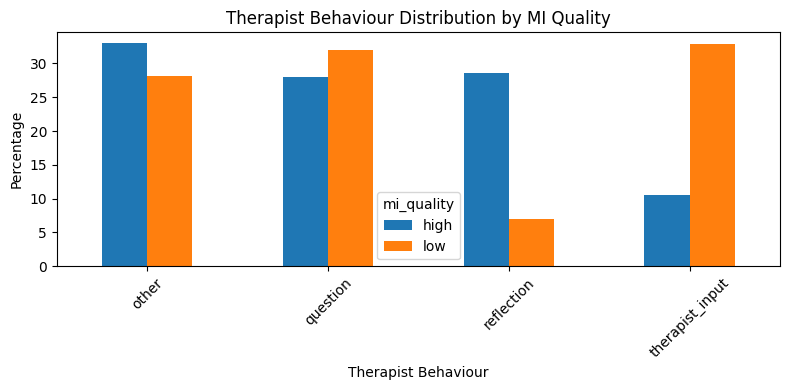

In [38]:
therapist_eda = therapist_df.dropna(subset=["main_therapist_behaviour", "mi_quality"]).copy()

therapist_counts = (
    therapist_eda
    .groupby(["mi_quality", "main_therapist_behaviour"])
    .size()
    .reset_index(name="n")
)

therapist_counts["ratio"] = therapist_counts.groupby("mi_quality")["n"].transform(lambda s: s / s.sum())

therapist_pivot = therapist_counts.pivot(
    index="main_therapist_behaviour",
    columns="mi_quality",
    values="ratio"
).fillna(0)

print("Therapist behaviour distribution by MI quality (%)")
display((therapist_pivot * 100).round(2))

(therapist_pivot * 100).plot(kind="bar", figsize=(8, 4))
plt.title("Therapist Behaviour Distribution by MI Quality")
plt.xlabel("Therapist Behaviour")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Inspect transcript-level MI quality

In [39]:
if "mi_quality" in therapist_df.columns:
    print(therapist_df[["transcript_id", "mi_quality"]].drop_duplicates()["mi_quality"].value_counts(dropna=False))

mi_quality
high    110
low      23
Name: count, dtype: int64


Client talk distribution by MI quality (%)


mi_quality,high,low
client_talk_type,,
change,25.13,17.18
neutral,64.05,67.78
sustain,10.82,15.04


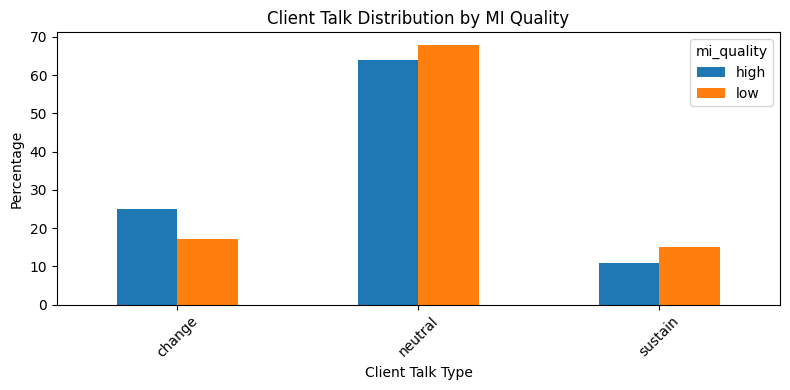

In [40]:
client_eda = client_df.dropna(subset=["client_talk_type", "mi_quality"]).copy()

client_counts = (
    client_eda
    .groupby(["mi_quality", "client_talk_type"])
    .size()
    .reset_index(name="n")
)

client_counts["ratio"] = client_counts.groupby("mi_quality")["n"].transform(lambda s: s / s.sum())

client_pivot = client_counts.pivot(
    index="client_talk_type",
    columns="mi_quality",
    values="ratio"
).fillna(0)

print("Client talk distribution by MI quality (%)")
display((client_pivot * 100).round(2))

(client_pivot * 100).plot(kind="bar", figsize=(8, 4))
plt.title("Client Talk Distribution by MI Quality")
plt.xlabel("Client Talk Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
print("=== Key Pattern Check ===")

if "reflection" in therapist_pivot.index:
    print("Reflection:", (therapist_pivot.loc["reflection"] * 100).round(2).to_dict())

if "therapist_input" in therapist_pivot.index:
    print("Therapist input:", (therapist_pivot.loc["therapist_input"] * 100).round(2).to_dict())

if "question" in therapist_pivot.index:
    print("Question:", (therapist_pivot.loc["question"] * 100).round(2).to_dict())

if "change" in client_pivot.index:
    print("Change talk:", (client_pivot.loc["change"] * 100).round(2).to_dict())

if "sustain" in client_pivot.index:
    print("Sustain talk:", (client_pivot.loc["sustain"] * 100).round(2).to_dict())

=== Key Pattern Check ===
Reflection: {'high': 28.51, 'low': 7.03}
Therapist input: {'high': 10.52, 'low': 32.88}
Question: {'high': 28.03, 'low': 31.97}
Change talk: {'high': 25.13, 'low': 17.18}
Sustain talk: {'high': 10.82, 'low': 15.04}


High-quality MI sessions are characterised by a higher proportion of reflective statements and a lower proportion of directive input, whereas low-quality sessions exhibit the opposite pattern. High MI therapist tends to listen and reflect, while low MI therapist tends to tell and direct.

- Reflection ↑ in high MI because it encourages client's change talk  
- Input ↑ in low MI because it triggers client's sustain talk (resistance)

### Class Examples





In [42]:
therapist_labels = therapist_df["main_therapist_behaviour"].dropna().unique().tolist()
print("Examples of main_therapist_behaviour:")
for therapist_label in sorted(therapist_labels):
    print(f"\n===== Therapist: {therapist_label} =====")
    sample_rows = therapist_df[therapist_df["main_therapist_behaviour"] == therapist_label][["utterance_text"]].head(3)
    for i, txt in enumerate(sample_rows["utterance_text"], 1):
        print(f"{i}. {txt}")

Examples of main_therapist_behaviour:

===== Therapist: other =====
1. Great. So, let's see how well you're doing with these new meds.
2. Okay.
3. Okay. Good.

===== Therapist: question =====
1. Thanks for filling it out. We give this form to everyone once a year regardless of why they come in. It helps us provide better care. Is it okay if I take a look at what you put down?
2. Uh, what else can you tell me about your drinking.
3. Okay. So, can I share with you some information on alcohol use?

===== Therapist: reflection =====
1. Right. By the way, binge drinking is defined for women as having more than, uh, three drinks and there are about five drinks in a bottle. So, you enjoy drinking wine because it helps make things, uh, a little bit more interesting when you're feeling down but at the same time you don't like drinking when you have more than you want it to and then the depression returns after you drink.
2. Having less wine in the house will help?
3. So, it's not just wine that

In [43]:
client_labels = client_df["client_talk_type"].dropna().unique().tolist()
print("Examples of client_talk_type:")
for client_label in sorted(client_labels ):
    print(f"\n===== Client: {client_label} =====")
    sample_rows = client_df[client_df["client_talk_type"] == client_label][["utterance_text"]].head(3)
    for i, txt in enumerate(sample_rows["utterance_text"], 1):
        print(f"{i}. {txt}")

Examples of client_talk_type:

===== Client: change =====
1. Well, I don't think that I'm ready to cut down to seven drinks a week. That seems like a lot but I would consider cutting back to two drinks a night. I think that would be my goal.
2. I'd say an eight.
3. Well, I'm more ready than a six because I'm ready to cut back on my drinking and I don't wanna make my depression any worse.

===== Client: neutral =====
1. Sure.
2. Mm-hmm.
3. Usually three drinks and glasses of wine.

===== Client: sustain =====
1. Yeah, but only on the weekend.
2. So, uh, are you saying I drink too much?
3. Well, I-- If-if I was getting fallen down drunk or if I drink every night. Um, it's not like I get sloppy drunk or anything.


---

# IV. End-to-End Pipeline

This section implements the full methodology:

Utterance → 2 classifiers → predicted labels → aggregation → MI_quality

The pipeline has two main stages:

1. Utterance-level classification
   - Therapist utterances: utterance_text → main_therapist_behaviour
   - Client utterances: utterance_text → client_talk_type

2. Session-level MI quality prediction
   - Aggregate predicted utterance labels into transcript-level behavioural ratios
   - Use these transcript-level ratios to predict mi_quality

Note: The data is split at the transcript level, not the utterance level, so that the test transcripts remain fully held out.

## 4.1 Transcript-Level Train-Ttest Split

The data is first split by transcript_id.

- session_train contains training transcripts
- session_test contains held-out test transcripts

This is important because MI quality is a session-level label.
Mixing utterances should be avoided from the same transcript across train and test.

In [44]:
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

session_labels = (
    df_consensus[["transcript_id", "mi_quality"]]
    .drop_duplicates()
    .copy()
)

session_labels["mi_quality"] = session_labels["mi_quality"].astype(str).str.strip().str.lower()
session_labels["mi_quality_binary"] = session_labels["mi_quality"].map({"low": 0, "high": 1})

session_train, session_test = train_test_split(
    session_labels,
    test_size=0.30,
    random_state=42,
    stratify=session_labels["mi_quality"]
)

train_ids = set(session_train["transcript_id"])
test_ids = set(session_test["transcript_id"])

print("Train sessions:", len(train_ids))
print("Test sessions :", len(test_ids))
print("\nTrain MI quality:")
print(session_train["mi_quality"].value_counts())
print("\nTest MI quality:")
print(session_test["mi_quality"].value_counts())

Train sessions: 93
Test sessions : 40

Train MI quality:
mi_quality
high    77
low     16
Name: count, dtype: int64

Test MI quality:
mi_quality
high    33
low      7
Name: count, dtype: int64


## 4.2. Therapist Utterance Classifier

Goal: Predict main_therapist_behaviour from therapist utterance_text.

Output:
- Out-of-fold predictions for training transcripts
- Held-out predictions for test transcripts

In [45]:
therapist_data = therapist_df[
    therapist_df["main_therapist_behaviour"].notna()
].copy()

therapist_data["utterance_text"] = (
    therapist_data["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

therapist_data = therapist_data[therapist_data["utterance_text"] != ""].copy()

therapist_train = therapist_data[
    therapist_data["transcript_id"].isin(train_ids)
].copy()

therapist_test = therapist_data[
    therapist_data["transcript_id"].isin(test_ids)
].copy()

therapist_encoder = LabelEncoder()
therapist_train["therapist_y"] = therapist_encoder.fit_transform(
    therapist_train["main_therapist_behaviour"]
)
therapist_test["therapist_y"] = therapist_encoder.transform(
    therapist_test["main_therapist_behaviour"]
)

print("Therapist train shape:", therapist_train.shape)
print("Therapist test shape :", therapist_test.shape)
print("\nTherapist classes:", list(therapist_encoder.classes_))

Therapist train shape: (3194, 9)
Therapist test shape : (1688, 9)

Therapist classes: ['other', 'question', 'reflection', 'therapist_input']


In [46]:
therapist_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words="english")),
    ("clf", LinearSVC())
])

therapist_gkf = GroupKFold(n_splits=5)

therapist_train_pred = cross_val_predict(
    therapist_model,
    therapist_train["utterance_text"],
    therapist_train["therapist_y"],
    cv=therapist_gkf.split(
        therapist_train["utterance_text"],
        therapist_train["therapist_y"],
        groups=therapist_train["transcript_id"]
    ),
    method="predict"
)

therapist_model.fit(
    therapist_train["utterance_text"],
    therapist_train["therapist_y"]
)

therapist_test_pred = therapist_model.predict(
    therapist_test["utterance_text"]
)

therapist_train["pred_main_therapist_behaviour"] = therapist_encoder.inverse_transform(therapist_train_pred)
therapist_test["pred_main_therapist_behaviour"] = therapist_encoder.inverse_transform(therapist_test_pred)

print("Therapist train OOF accuracy:", accuracy_score(therapist_train["therapist_y"], therapist_train_pred))
print("Therapist test accuracy     :", accuracy_score(therapist_test["therapist_y"], therapist_test_pred))

print("\nTherapist classification report:")
print(classification_report(
    therapist_test["therapist_y"],
    therapist_test_pred,
    target_names=therapist_encoder.classes_
))

Therapist train OOF accuracy: 0.5970569818409518
Therapist test accuracy     : 0.6113744075829384

Therapist classification report:
                 precision    recall  f1-score   support

          other       0.81      0.80      0.81       561
       question       0.55      0.54      0.54       527
     reflection       0.53      0.55      0.54       429
therapist_input       0.37      0.36      0.37       171

       accuracy                           0.61      1688
      macro avg       0.56      0.56      0.56      1688
   weighted avg       0.61      0.61      0.61      1688



## 4.3 Client Utterance Classifier

Goal:
Predict client_talk_type from client utterance_text.

Output:
- Out-of-fold predictions for training transcripts
- Held-out predictions for test transcripts

In [47]:
client_data = client_df[
    client_df["client_talk_type"].notna()
].copy()

client_data["utterance_text"] = (
    client_data["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

client_data = client_data[client_data["utterance_text"] != ""].copy()

client_train = client_data[
    client_data["transcript_id"].isin(train_ids)
].copy()

client_test = client_data[
    client_data["transcript_id"].isin(test_ids)
].copy()

client_encoder = LabelEncoder()
client_train["client_y"] = client_encoder.fit_transform(
    client_train["client_talk_type"]
)
client_test["client_y"] = client_encoder.transform(
    client_test["client_talk_type"]
)

print("Client train shape:", client_train.shape)
print("Client test shape: ", client_test.shape)
print("\nClient classes:", list(client_encoder.classes_))

Client train shape: (3153, 9)
Client test shape : (1664, 9)

Client classes: ['change', 'neutral', 'sustain']


In [48]:
client_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words="english")),
    ("clf", LinearSVC())
])

client_gkf = GroupKFold(n_splits=5)

client_train_pred = cross_val_predict(
    client_model,
    client_train["utterance_text"],
    client_train["client_y"],
    cv=client_gkf.split(
        client_train["utterance_text"],
        client_train["client_y"],
        groups=client_train["transcript_id"]
    ),
    method="predict"
)

client_model.fit(
    client_train["utterance_text"],
    client_train["client_y"]
)

client_test_pred = client_model.predict(
    client_test["utterance_text"]
)

client_train["pred_client_talk_type"] = client_encoder.inverse_transform(client_train_pred)
client_test["pred_client_talk_type"] = client_encoder.inverse_transform(client_test_pred)

print("Client train OOF accuracy:", accuracy_score(client_train["client_y"], client_train_pred))
print("Client test accuracy     :", accuracy_score(client_test["client_y"], client_test_pred))

print("\nClient classification report:")
print(classification_report(
    client_test["client_y"],
    client_test_pred,
    target_names=client_encoder.classes_
))

Client train OOF accuracy: 0.6387567396130669
Client test accuracy     : 0.6105769230769231

Client classification report:
              precision    recall  f1-score   support

      change       0.44      0.25      0.32       446
     neutral       0.66      0.86      0.75      1010
     sustain       0.38      0.15      0.22       208

    accuracy                           0.61      1664
   macro avg       0.49      0.42      0.43      1664
weighted avg       0.56      0.61      0.57      1664



## 4.4 Predicted Label Aggregation

At this stage, gold utterance labels are not used. Instead, aggregate therapist and client predicted labels:
- pred_main_therapist_behaviour
- pred_client_talk_type

into transcript-level ratios such as:
- reflection_ratio
- question_ratio
- input_ratio
- change_ratio
- sustain_ratio

These aggregated features form the session-level representation.

In [49]:
def build_session_features(therapist_pred_df, client_pred_df, session_df):
    therapist_counts = (
        therapist_pred_df
        .groupby(["transcript_id", "pred_main_therapist_behaviour"])
        .size()
        .unstack(fill_value=0)
    )

    client_counts = (
        client_pred_df
        .groupby(["transcript_id", "pred_client_talk_type"])
        .size()
        .unstack(fill_value=0)
    )

    for col in ["reflection", "question", "therapist_input", "other"]:
        if col not in therapist_counts.columns:
            therapist_counts[col] = 0

    for col in ["change", "sustain", "neutral"]:
        if col not in client_counts.columns:
            client_counts[col] = 0

    therapist_counts["therapist_total"] = therapist_counts[["reflection", "question", "therapist_input", "other"]].sum(axis=1)
    client_counts["client_total"] = client_counts[["change", "sustain", "neutral"]].sum(axis=1)

    therapist_counts["reflection_ratio"] = therapist_counts["reflection"] / therapist_counts["therapist_total"]
    therapist_counts["question_ratio"] = therapist_counts["question"] / therapist_counts["therapist_total"]
    therapist_counts["input_ratio"] = therapist_counts["therapist_input"] / therapist_counts["therapist_total"]

    client_counts["change_ratio"] = client_counts["change"] / client_counts["client_total"]
    client_counts["sustain_ratio"] = client_counts["sustain"] / client_counts["client_total"]

    session_features = (
        session_df
        .merge(
            therapist_counts[["reflection_ratio", "question_ratio", "input_ratio"]],
            left_on="transcript_id",
            right_index=True,
            how="left"
        )
        .merge(
            client_counts[["change_ratio", "sustain_ratio"]],
            left_on="transcript_id",
            right_index=True,
            how="left"
        )
        .fillna(0)
    )

    return session_features

In [56]:
session_train_features = build_session_features(
    therapist_train[["transcript_id", "pred_main_therapist_behaviour"]],
    client_train[["transcript_id", "pred_client_talk_type"]],
    session_train
)

session_test_features = build_session_features(
    therapist_test[["transcript_id", "pred_main_therapist_behaviour"]],
    client_test[["transcript_id", "pred_client_talk_type"]],
    session_test
)

print("Session train features shape:", session_train_features.shape)
display(session_train_features.head())
print("Session test features shape:", session_test_features.shape)
display(session_test_features.head())

Session train features shape: (93, 8)


,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio
6119,92,low,0,0.142857,0.285714,0.285714,0.333333,0.000000
3316,53,low,0,0.259259,0.222222,0.296296,0.203704,0.037037
8971,126,low,0,0.194444,0.277778,0.416667,0.285714,0.000000
7615,111,high,1,0.300000,0.500000,0.100000,0.068966,0.068966
5467,84,high,1,0.279661,0.381356,0.008475,0.145299,0.017094


Session test features shape: (40, 8)


,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio
1981,35,high,1,0.555556,0.277778,0.000000,0.294118,0.058824
7674,112,high,1,0.272727,0.181818,0.090909,0.125000,0.062500
798,18,high,1,0.344828,0.206897,0.068966,0.192982,0.052632
6455,98,high,1,0.223350,0.324873,0.111675,0.167513,0.065990
4744,70,high,1,0.000000,0.333333,0.333333,0.166667,0.000000


## 4.5. Session-Level MI Quality Prediction

Goal: Use transcript-level behavioural ratios to predict mi_quality.

This is the final stage of the end-to-end pipeline:

Predicted utterance labels → Aggregated session features → Session-level MI quality.

In [51]:
session_feature_cols = [
    "reflection_ratio",
    "question_ratio",
    "input_ratio",
    "change_ratio",
    "sustain_ratio"
]

session_model = LogisticRegression(max_iter=1000)

session_model.fit(
    session_train_features[session_feature_cols],
    session_train_features["mi_quality_binary"]
)

session_test_pred = session_model.predict(
    session_test_features[session_feature_cols]
)

print("Final MI_quality accuracy:", accuracy_score(session_test_features["mi_quality_binary"], session_test_pred))
print("\nSession-level classification report:")
print(classification_report(
    session_test_features["mi_quality_binary"],
    session_test_pred,
    target_names=["low", "high"]
))

Final MI_quality accuracy: 0.825

Session-level classification report:
              precision    recall  f1-score   support

         low       0.00      0.00      0.00         7
        high       0.82      1.00      0.90        33

    accuracy                           0.82        40
   macro avg       0.41      0.50      0.45        40
weighted avg       0.68      0.82      0.75        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


---

# V. Evaluation and Error Analysis

This section evaluates model performance in more detail using confusion matrices and per-class metrics.
We also inspect misclassified therapist utterances to better understand model limitations.

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## 5.1. Therapist & Client Confusion Matrix

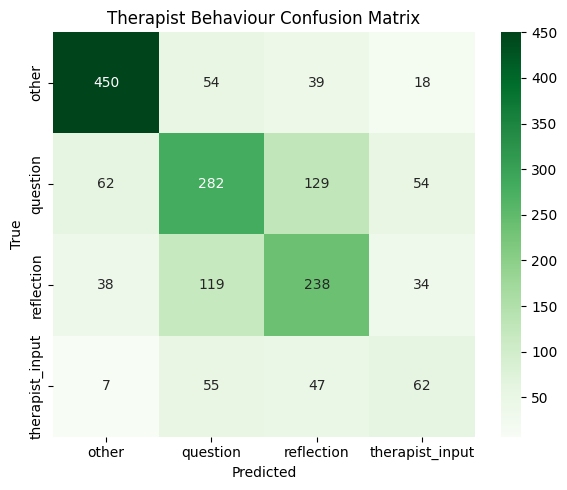

In [53]:
# A. Therapist confusion matrix
therapist_cm = confusion_matrix(therapist_test["therapist_y"], therapist_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    therapist_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=therapist_encoder.classes_,
    yticklabels=therapist_encoder.classes_
)
plt.title("Therapist Behaviour Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

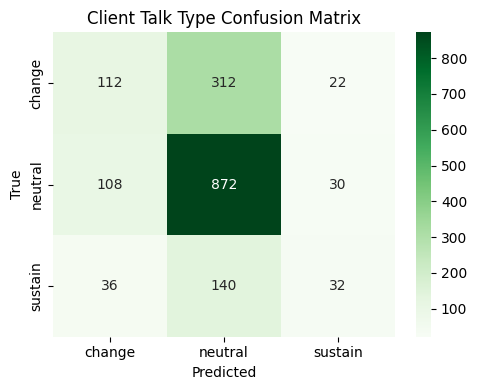

In [54]:
# B. Client confusion matrix
client_cm = confusion_matrix(client_test["client_y"], client_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    client_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=client_encoder.classes_,
    yticklabels=client_encoder.classes_
)
plt.title("Client Talk Type Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 5.2. Session Feature Coefficients

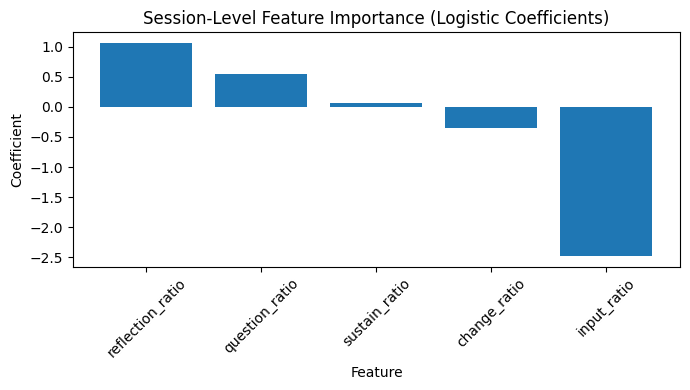

,feature,coefficient
0,reflection_ratio,1.058713
1,question_ratio,0.538193
4,sustain_ratio,0.065775
3,change_ratio,-0.345680
2,input_ratio,-2.475997


In [55]:
coef_df = pd.DataFrame({
    "feature": session_feature_cols,
    "coefficient": session_model.coef_[0]
}).sort_values("coefficient", ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(coef_df["feature"], coef_df["coefficient"])
plt.title("Session-Level Feature Importance (Logistic Coefficients)")
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(coef_df)

---

## 6.5. Thesis-ready interpretation

At this point the pipeline does two things:

1. **Utterance-level behaviour classification** using the main therapist behaviour label.  
2. **Session-level fidelity analysis** using fine-grained subtype annotations from **AnnoMI-full**.

This is a stronger thesis framing than classification alone because it connects model outputs to clinically meaningful fidelity indicators such as:
- open question ratio
- complex reflection ratio
- reflection-to-question ratio
- advice ratio
